# 07 — Single Dataset Model Experiment

This notebook validates the final experiment pipeline on one dataset before scaling to all datasets on HPC.

Experiment unit:

dataset × model × horizon type × horizon

This notebook records:
- MAE
- RMSE
- sMAPE
- fit time
- inference time
- total runtime
- peak memory usage

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from src.data.dataset_loader import load_monash_dataset
from src.experiments.run_model_experiment import run_model_experiment

Importing plotly failed. Interactive plots will not work.


In [3]:
DATASET_KEY = "electricity_weekly"

MODELS = [
    "naive",
    "seasonal_naive",
    "arima",
    "prophet",
    "lstm",
    "timesfm",
    "ttm",
    "uni2ts",
]

HORIZON_CONFIG = {
    "short": 4,
    "long": 8,
}

OUTPUT_DIR = Path("results/raw_runs")

In [4]:
bundle = load_monash_dataset(DATASET_KEY)

dataset_info = {
    "dataset_key": bundle["dataset_key"],
    "domain": bundle["domain"],
    "frequency": bundle["normalized_frequency"],
    "default_horizon": bundle["resolved_horizon"],
    "horizon_strategy": bundle["horizon_strategy"],
    "num_series": len(bundle["records_df"]),
    "num_long_rows": len(bundle["long_df"]),
}

dataset_info

{'dataset_key': 'electricity_weekly',
 'domain': 'energy',
 'frequency': 'weekly',
 'default_horizon': 8,
 'horizon_strategy': 'metadata',
 'num_series': 321,
 'num_long_rows': 50076}

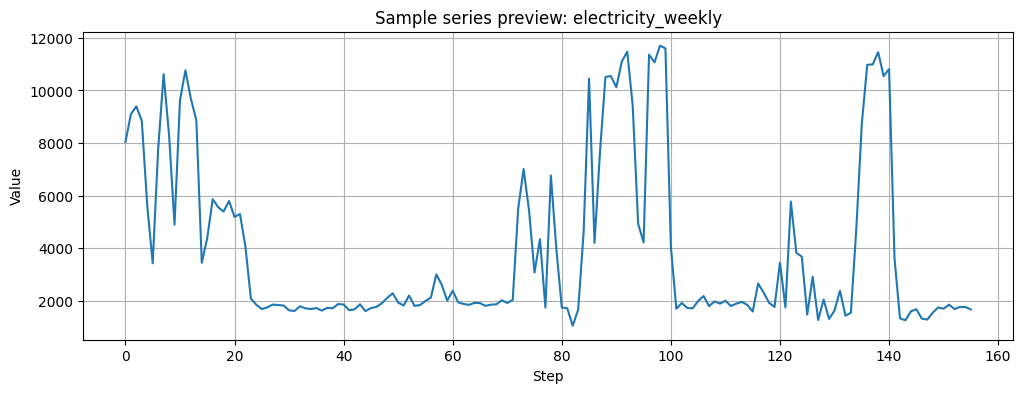

In [5]:
records_df = bundle["records_df"]
first_series = records_df.iloc[0]
values = first_series["series_values"][:500]

plt.figure(figsize=(12, 4))
plt.plot(values)
plt.title(f"Sample series preview: {DATASET_KEY}")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [6]:
run_outputs = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"Running horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning model: {model_name}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="baseline",
            output_dir=OUTPUT_DIR,
            series_limit=None,
            save_results=True,
        )

        run_outputs.append(result_df)

print("All runs completed.")


Running horizon: short | h=4

Running model: naive
Saved: results/raw_runs/energy/electricity_weekly/naive_short_h4_baseline.csv

Running model: seasonal_naive
Saved: results/raw_runs/energy/electricity_weekly/seasonal_naive_short_h4_baseline.csv

Running model: arima
Saved: results/raw_runs/energy/electricity_weekly/arima_short_h4_baseline.csv

Running model: prophet


INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/energy/electricity_weekly/prophet_short_h4_baseline.csv

Running model: lstm
Saved: results/raw_runs/energy/electricity_weekly/lstm_short_h4_baseline.csv

Running model: timesfm


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 19130.23it/s]
INFO:p-41376:t-8556863680:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from local directory: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3
INFO:p-41376:t-8556863680:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/model.safetensors


Compiling model...
Saved: results/raw_runs/energy/electricity_weekly/timesfm_short_h4_baseline.csv

Running model: ttm


...

Saved: results/raw_runs/energy/electricity_weekly/ttm_short_h4_baseline.csv

Running model: uni2ts
Saved: results/raw_runs/energy/electricity_weekly/uni2ts_short_h4_baseline.csv

Running horizon: long | h=8

Running model: naive
Saved: results/raw_runs/energy/electricity_weekly/naive_long_h8_baseline.csv

Running model: seasonal_naive
Saved: results/raw_runs/energy/electricity_weekly/seasonal_naive_long_h8_baseline.csv

Running model: arima
Saved: results/raw_runs/energy/electricity_weekly/arima_long_h8_baseline.csv

Running model: prophet


INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/energy/electricity_weekly/prophet_long_h8_baseline.csv

Running model: lstm
Saved: results/raw_runs/energy/electricity_weekly/lstm_long_h8_baseline.csv

Running model: timesfm
Saved: results/raw_runs/energy/electricity_weekly/timesfm_long_h8_baseline.csv

Running model: ttm


INFO:p-41376:t-8556863680:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-41376:t-8556863680:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 90-30-ft-r2.1.
INFO:p-41376:t-8556863680:get_model.py:get_model:[TTM] context_length = 90, prediction_length = 30
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set 

Saved: results/raw_runs/energy/electricity_weekly/ttm_long_h8_baseline.csv

Running model: uni2ts
Saved: results/raw_runs/energy/electricity_weekly/uni2ts_long_h8_baseline.csv
All runs completed.


In [7]:
combined_df = pd.concat(run_outputs, ignore_index=True)

combined_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,max_context,max_horizon,normalize_inputs,use_continuous_quantile_head,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,electricity_weekly,energy,weekly,naive,4,130.50,137.504545,7.350787,1.192093e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T2,electricity_weekly,energy,weekly,naive,4,220.25,252.044143,1.392786,9.536743e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T3,electricity_weekly,energy,weekly,naive,4,47.75,95.500000,3.886854,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T4,electricity_weekly,energy,weekly,naive,4,8575.25,9474.712727,9.343693,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T5,electricity_weekly,energy,weekly,naive,4,6265.00,6891.614325,14.102558,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
failed_df = combined_df[combined_df["status"] != "success"].copy()

failed_df[["dataset_key", "model", "horizon_type", "series_id", "error_message"]].head(20)

,dataset_key,model,horizon_type,series_id,error_message


In [9]:
accuracy_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_summary_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,electricity_weekly,weekly,seasonal_naive,long,8,321,26351.785047,30367.679003,10.672020
1,electricity_weekly,weekly,arima,long,8,321,72694.114533,75674.004022,13.957595
2,electricity_weekly,weekly,naive,long,8,321,72228.983645,75198.821903,14.139393
3,electricity_weekly,weekly,timesfm,long,8,321,72228.983645,75198.821903,14.139393
4,electricity_weekly,weekly,prophet,long,8,321,85581.605287,88726.212008,17.848835
5,electricity_weekly,weekly,ttm,long,8,321,89644.301661,92599.941014,17.926161
6,electricity_weekly,weekly,uni2ts,long,8,321,171016.822487,174277.098607,23.329547
7,electricity_weekly,weekly,lstm,long,8,321,364915.217869,365558.158827,199.992741
8,electricity_weekly,weekly,arima,short,4,321,20611.857229,23983.438735,8.330778
9,electricity_weekly,weekly,naive,short,4,321,20644.941589,24001.709891,8.373332


In [10]:
best_idx = accuracy_summary_df.groupby("horizon_type")["smape"].idxmin()

best_model_per_horizon_df = accuracy_summary_df.loc[
    best_idx,
    ["horizon_type", "horizon", "model", "smape", "mae", "rmse"]
].reset_index(drop=True)

best_model_per_horizon_df

,horizon_type,horizon,model,smape,mae,rmse
0,long,8,seasonal_naive,10.672020,26351.785047,30367.679003
1,short,4,arima,8.330778,20611.857229,23983.438735


In [11]:
runtime_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

runtime_summary_df

,model,horizon_type,horizon,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,naive,long,8,8.972263e-07,0.000007,0.000009,0.398567,321
1,seasonal_naive,long,8,2.792691e-07,0.000019,0.000020,0.410645,321
2,arima,long,8,5.629947e-07,0.024603,0.024606,2.568929,321
3,prophet,long,8,3.525773e-06,0.125162,0.125168,6.750389,321
4,lstm,long,8,8.556330e-07,0.241609,0.241613,0.783119,321
5,timesfm,long,8,1.172782e-06,0.341045,0.341051,0.606168,321
6,ttm,long,8,1.005666e-06,1.144991,1.144996,2.902194,321
7,uni2ts,long,8,9.848693e-07,1.192746,1.192751,3.515956,321
8,naive,short,4,3.490864e-07,0.000005,0.000007,0.402198,321
9,seasonal_naive,short,4,3.178914e-07,0.000018,0.000020,0.412161,321


In [12]:
horizon_comparison_df = accuracy_summary_df.pivot_table(
    index="model",
    columns="horizon_type",
    values="smape",
    aggfunc="mean",
).reset_index()

horizon_comparison_df["smape_change_long_minus_short"] = (
    horizon_comparison_df["long"] - horizon_comparison_df["short"]
)

horizon_comparison_df = horizon_comparison_df.sort_values("long").reset_index(drop=True)

horizon_comparison_df

horizon_type,model,long,short,smape_change_long_minus_short
0,seasonal_naive,10.672020,10.679043,-0.007023
1,arima,13.957595,8.330778,5.626816
2,naive,14.139393,8.373332,5.766061
3,timesfm,14.139393,8.373332,5.766061
4,prophet,17.848835,18.294101,-0.445266
5,ttm,17.926161,21.770300,-3.844138
6,uni2ts,23.329547,16.340621,6.988926
7,lstm,199.992741,199.992437,0.000305


In [20]:
def map_model_family(model_name: str) -> str:
    if model_name in {"naive", "seasonal_naive", "arima", "prophet", "lstm"}:
        return "traditional"
    if model_name in {"timesfm", "ttm", "uni2ts"}:
        return "foundation"
    return "other"


accuracy_summary_df["model_family"] = accuracy_summary_df["model"].apply(map_model_family)
runtime_summary_df["model_family"] = runtime_summary_df["model"].apply(map_model_family)

accuracy_summary_df.head()

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape,model_family
0,electricity_weekly,weekly,seasonal_naive,long,8,321,26351.785047,30367.679003,10.672020,traditional
1,electricity_weekly,weekly,arima,long,8,321,72694.114533,75674.004022,13.957595,traditional
2,electricity_weekly,weekly,naive,long,8,321,72228.983645,75198.821903,14.139393,traditional
3,electricity_weekly,weekly,timesfm,long,8,321,72228.983645,75198.821903,14.139393,foundation
4,electricity_weekly,weekly,prophet,long,8,321,85581.605287,88726.212008,17.848835,traditional


In [21]:
family_accuracy_df = (
    accuracy_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_mae=("mae", "mean"),
        avg_rmse=("rmse", "mean"),
        avg_smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "avg_smape"])
    .reset_index(drop=True)
)

family_accuracy_df

,model_family,horizon_type,avg_mae,avg_rmse,avg_smape
0,foundation,long,110963.369264,114025.287175,18.465034
1,traditional,long,124354.341276,127104.975152,51.322117
2,foundation,short,73174.823693,75767.040060,15.494751
3,traditional,short,102911.039444,105203.317538,49.133938


In [22]:
family_runtime_df = (
    runtime_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_fit_time_seconds=("avg_fit_time_seconds", "mean"),
        avg_inference_time_seconds=("avg_inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("avg_series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

family_runtime_df

,model_family,horizon_type,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
0,traditional,long,1.224179e-06,0.078280,0.078283,2.182330
1,foundation,long,1.054439e-06,0.892928,0.892933,2.341439
2,traditional,short,1.086030e-06,0.078882,0.078885,2.774341
3,foundation,short,8.900465e-07,0.875825,0.875829,6.466470


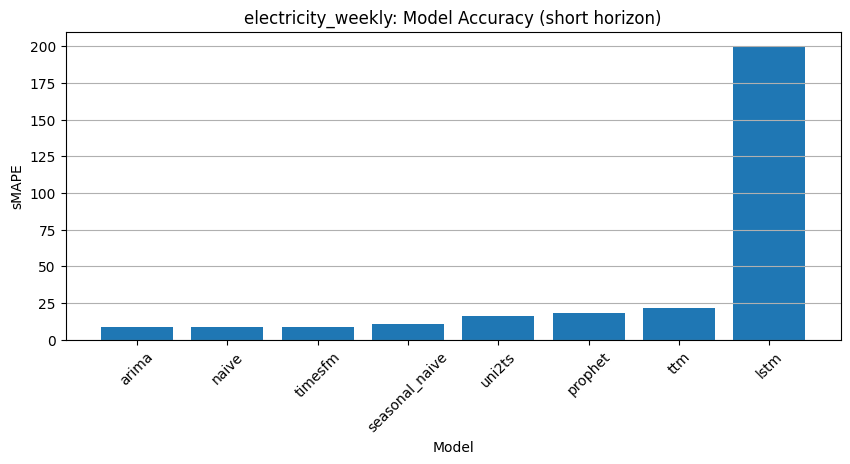

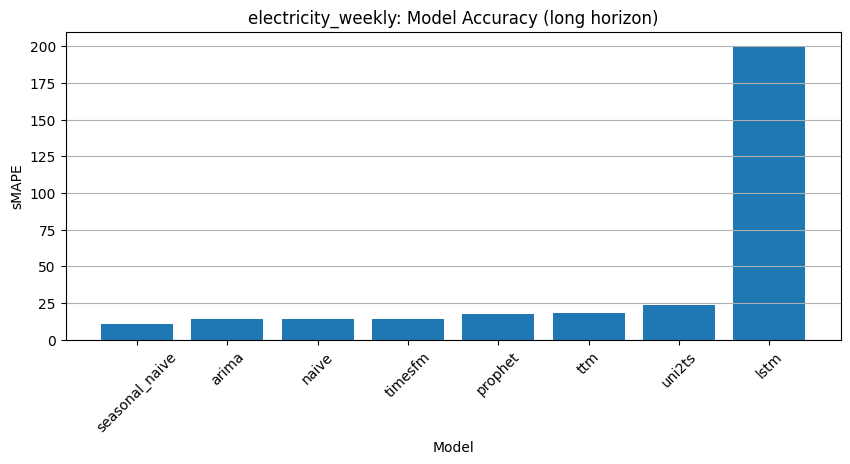

In [23]:
for horizon_type in HORIZON_CONFIG.keys():
    subset = accuracy_summary_df[accuracy_summary_df["horizon_type"] == horizon_type].copy()
    subset = subset.sort_values("smape")

    plt.figure(figsize=(10, 4))
    plt.bar(subset["model"], subset["smape"])
    plt.title(f"{DATASET_KEY}: Model Accuracy ({horizon_type} horizon)")
    plt.xlabel("Model")
    plt.ylabel("sMAPE")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

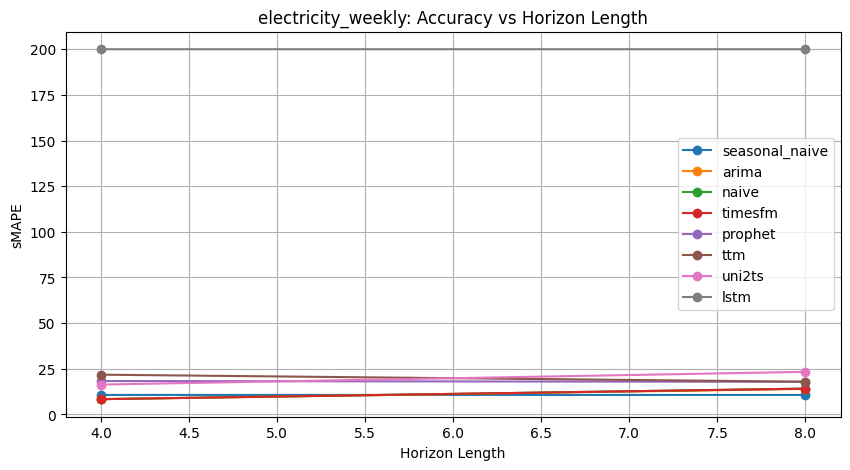

In [24]:
plot_df = accuracy_summary_df.copy()

plt.figure(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    subset = plot_df[plot_df["model"] == model_name].sort_values("horizon")
    plt.plot(subset["horizon"], subset["smape"], marker="o", label=model_name)

plt.title(f"{DATASET_KEY}: Accuracy vs Horizon Length")
plt.xlabel("Horizon Length")
plt.ylabel("sMAPE")
plt.legend()
plt.grid(True)
plt.show()

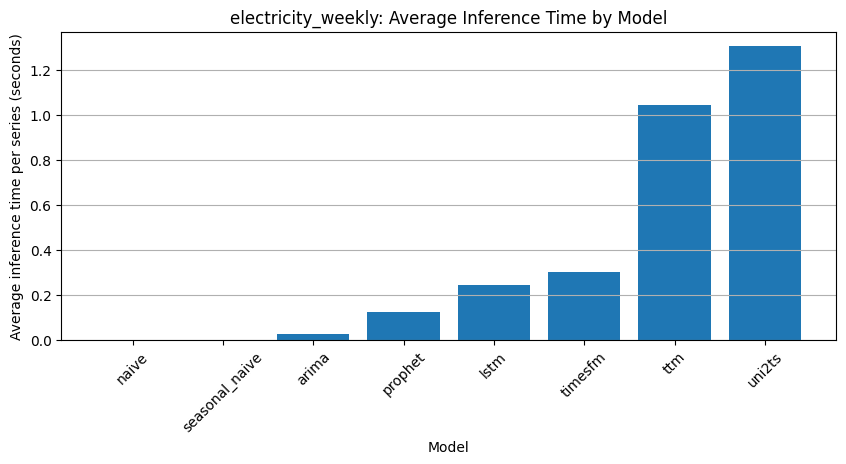

In [25]:
runtime_plot_df = (
    runtime_summary_df
    .groupby("model", as_index=False)["avg_inference_time_seconds"]
    .mean()
    .sort_values("avg_inference_time_seconds")
)

plt.figure(figsize=(10, 4))
plt.bar(runtime_plot_df["model"], runtime_plot_df["avg_inference_time_seconds"])
plt.title(f"{DATASET_KEY}: Average Inference Time by Model")
plt.xlabel("Model")
plt.ylabel("Average inference time per series (seconds)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [26]:
final_dir = Path("results/aggregated")
final_dir.mkdir(parents=True, exist_ok=True)

accuracy_summary_df.to_csv(final_dir / f"{DATASET_KEY}_accuracy_summary.csv", index=False)
best_model_per_horizon_df.to_csv(final_dir / f"{DATASET_KEY}_best_model_per_horizon.csv", index=False)
runtime_summary_df.to_csv(final_dir / f"{DATASET_KEY}_runtime_summary.csv", index=False)
horizon_comparison_df.to_csv(final_dir / f"{DATASET_KEY}_horizon_comparison.csv", index=False)
family_accuracy_df.to_csv(final_dir / f"{DATASET_KEY}_family_accuracy.csv", index=False)
family_runtime_df.to_csv(final_dir / f"{DATASET_KEY}_family_runtime.csv", index=False)

print("Saved outputs to:", final_dir)

Saved outputs to: results/aggregated


## Initial Findings

This single-dataset experiment evaluates all traditional, deep learning, and foundation models on both short and long forecasting horizons.

Key points to inspect:
- Which model has the lowest sMAPE for the short horizon?
- Which model has the lowest sMAPE for the long horizon?
- Does model ranking change as horizon length increases?
- Do foundation models improve or degrade more slowly than traditional models?
- Which models are fastest at inference?
- Which models have the highest memory usage?

This notebook validates the final experiment structure before scaling to all datasets on HPC.

In [27]:
baseline_accuracy_df = accuracy_summary_df.copy()
baseline_runtime_df = runtime_summary_df.copy()

print("Baseline saved.")

Baseline saved.


In [28]:
TUNED_MODEL_PARAMS = {
    "arima": {"order": (2, 1, 2)},
    
    "lstm": {
        "hidden_size": 128,
        "num_layers": 2,
        "epochs": 50,
        "learning_rate": 0.0005,
    },

    "timesfm": {
        "max_context": 1024,
    },

    "naive": {},
    "seasonal_naive": {},
    "prophet": {},
    "ttm": {},
    "uni2ts": {},
}

In [29]:
run_outputs_tuned = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"TUNED → horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning tuned model: {model_name}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="tuned",
            output_dir=OUTPUT_DIR,
            model_params=TUNED_MODEL_PARAMS.get(model_name, {}),
            series_limit=None,
            save_results=True,
        )

        run_outputs_tuned.append(result_df)

print("All tuned runs completed.")


TUNED → horizon: short | h=4

Running tuned model: naive
Saved: results/raw_runs/energy/electricity_weekly/naive_short_h4_tuned.csv

Running tuned model: seasonal_naive
Saved: results/raw_runs/energy/electricity_weekly/seasonal_naive_short_h4_tuned.csv

Running tuned model: arima


/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-time

Saved: results/raw_runs/energy/electricity_weekly/arima_short_h4_tuned.csv

Running tuned model: prophet


INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/energy/electricity_weekly/prophet_short_h4_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/energy/electricity_weekly/lstm_short_h4_tuned.csv

Running tuned model: timesfm
Saved: results/raw_runs/energy/electricity_weekly/timesfm_short_h4_tuned.csv

Running tuned model: ttm


...

Saved: results/raw_runs/energy/electricity_weekly/arima_long_h8_tuned.csv

Running tuned model: prophet


INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-41376:t-8556863680:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-41376:t-8556863680:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/energy/electricity_weekly/prophet_long_h8_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/energy/electricity_weekly/lstm_long_h8_tuned.csv

Running tuned model: timesfm
Saved: results/raw_runs/energy/electricity_weekly/timesfm_long_h8_tuned.csv

Running tuned model: ttm


Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set

Saved: results/raw_runs/energy/electricity_weekly/ttm_long_h8_tuned.csv

Running tuned model: uni2ts
Saved: results/raw_runs/energy/electricity_weekly/uni2ts_long_h8_tuned.csv
All tuned runs completed.


In [30]:
combined_tuned_df = pd.concat(run_outputs_tuned, ignore_index=True)

combined_tuned_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,max_context,max_horizon,normalize_inputs,use_continuous_quantile_head,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,electricity_weekly,energy,weekly,naive,4,130.50,137.504545,7.350787,4.053116e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T2,electricity_weekly,energy,weekly,naive,4,220.25,252.044143,1.392786,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T3,electricity_weekly,energy,weekly,naive,4,47.75,95.500000,3.886854,9.536743e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T4,electricity_weekly,energy,weekly,naive,4,8575.25,9474.712727,9.343693,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T5,electricity_weekly,energy,weekly,naive,4,6265.00,6891.614325,14.102558,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
accuracy_tuned_df = (
    combined_tuned_df[combined_tuned_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_tuned_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,electricity_weekly,weekly,seasonal_naive,long,8,321,26351.785047,30367.679003,10.672020
1,electricity_weekly,weekly,naive,long,8,321,72228.983645,75198.821903,14.139393
2,electricity_weekly,weekly,timesfm,long,8,321,72228.983645,75198.821903,14.139393
3,electricity_weekly,weekly,arima,long,8,321,75802.688664,79428.962954,14.838019
4,electricity_weekly,weekly,prophet,long,8,321,85581.605287,88726.212008,17.848835
5,electricity_weekly,weekly,ttm,long,8,321,89644.301661,92599.941014,17.926161
6,electricity_weekly,weekly,uni2ts,long,8,321,176694.084403,180965.429523,23.248149
7,electricity_weekly,weekly,lstm,long,8,321,364899.852280,365542.826570,199.840838
8,electricity_weekly,weekly,naive,short,4,321,20644.941589,24001.709891,8.373332
9,electricity_weekly,weekly,timesfm,short,4,321,20644.941589,24001.709891,8.373332


In [32]:
compare_df = baseline_accuracy_df.merge(
    accuracy_tuned_df,
    on=["model", "horizon_type"],
    suffixes=("_baseline", "_tuned"),
)

compare_df["smape_improvement"] = (
    compare_df["smape_baseline"] - compare_df["smape_tuned"]
)

compare_df = compare_df.sort_values(
    ["horizon_type", "smape_improvement"],
    ascending=[True, False]
)

compare_df

,dataset_key_baseline,frequency_baseline,model,horizon_type,horizon_baseline,n_series_baseline,mae_baseline,rmse_baseline,smape_baseline,model_family,dataset_key_tuned,frequency_tuned,horizon_tuned,n_series_tuned,mae_tuned,rmse_tuned,smape_tuned,smape_improvement
7,electricity_weekly,weekly,lstm,long,8,321,364915.217869,365558.158827,199.992741,traditional,electricity_weekly,weekly,8,321,364899.852280,365542.826570,199.840838,0.151903
6,electricity_weekly,weekly,uni2ts,long,8,321,171016.822487,174277.098607,23.329547,foundation,electricity_weekly,weekly,8,321,176694.084403,180965.429523,23.248149,0.081398
0,electricity_weekly,weekly,seasonal_naive,long,8,321,26351.785047,30367.679003,10.672020,traditional,electricity_weekly,weekly,8,321,26351.785047,30367.679003,10.672020,0.000000
2,electricity_weekly,weekly,naive,long,8,321,72228.983645,75198.821903,14.139393,traditional,electricity_weekly,weekly,8,321,72228.983645,75198.821903,14.139393,0.000000
3,electricity_weekly,weekly,timesfm,long,8,321,72228.983645,75198.821903,14.139393,foundation,electricity_weekly,weekly,8,321,72228.983645,75198.821903,14.139393,0.000000
4,electricity_weekly,weekly,prophet,long,8,321,85581.605287,88726.212008,17.848835,traditional,electricity_weekly,weekly,8,321,85581.605287,88726.212008,17.848835,0.000000
5,electricity_weekly,weekly,ttm,long,8,321,89644.301661,92599.941014,17.926161,foundation,electricity_weekly,weekly,8,321,89644.301661,92599.941014,17.926161,0.000000
1,electricity_weekly,weekly,arima,long,8,321,72694.114533,75674.004022,13.957595,traditional,electricity_weekly,weekly,8,321,75802.688664,79428.962954,14.838019,-0.880425
15,electricity_weekly,weekly,lstm,short,4,321,356249.713025,356588.503085,199.992437,traditional,electricity_weekly,weekly,4,321,356233.639924,356572.465209,199.824836,0.167600
12,electricity_weekly,weekly,uni2ts,short,4,321,78770.328940,81382.095154,16.340621,foundation,electricity_weekly,weekly,4,321,78855.860160,81388.098110,16.259449,0.081172


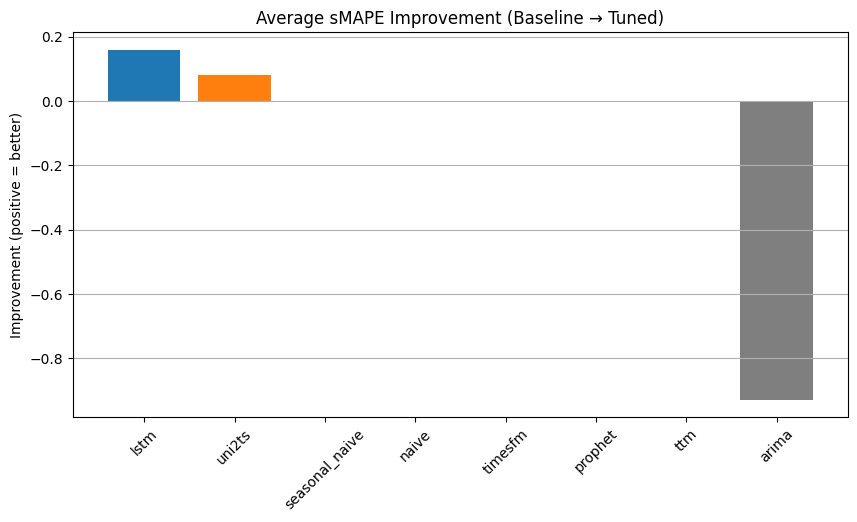

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in compare_df["model"].unique():
    subset = compare_df[compare_df["model"] == model]
    plt.bar(model, subset["smape_improvement"].mean())

plt.title("Average sMAPE Improvement (Baseline → Tuned)")
plt.ylabel("Improvement (positive = better)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()